In [1]:
import pandas as pd

df = pd.read_csv("/content/SuperMarket Analysis.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761

In [2]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows and columns:
(1000, 17)

Column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Data types:
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 

In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [4]:
print("\nTotal missing values:")
print(df.isnull().sum().sum())


Total missing values:
0


In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
categorical_columns = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

for column in categorical_columns:
    print("\n" + column)
    print(df[column].unique())


Branch
['Alex' 'Giza' 'Cairo']

City
['Yangon' 'Naypyitaw' 'Mandalay']

Customer type
['Member' 'Normal']

Gender
['Female' 'Male']

Product line
['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']

Payment
['Ewallet' 'Cash' 'Credit card']


In [7]:
numerical_columns = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

print(df[numerical_columns].describe())

        Unit price     Quantity       Tax 5%        Sales        cogs  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.00000   
mean     55.672130     5.510000    15.379369   322.966749   307.58738   
std      26.494628     2.923431    11.708825   245.885335   234.17651   
min      10.080000     1.000000     0.508500    10.678500    10.17000   
25%      32.875000     3.000000     5.924875   124.422375   118.49750   
50%      55.230000     5.000000    12.088000   253.848000   241.76000   
75%      77.935000     8.000000    22.445250   471.350250   448.90500   
max      99.960000    10.000000    49.650000  1042.650000   993.00000   

       gross margin percentage  gross income      Rating  
count             1.000000e+03   1000.000000  1000.00000  
mean              4.761905e+00     15.379369     6.97270  
std               6.131498e-14     11.708825     1.71858  
min               4.761905e+00      0.508500     4.00000  
25%               4.761905e+00      5.924875   

In [8]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Unit price
Lower bound: -34.715
Upper bound: 145.525
Number of outliers: 0

Quantity
Lower bound: -4.5
Upper bound: 15.5
Number of outliers: 0

Tax 5%
Lower bound: -18.855687500000002
Upper bound: 47.2258125
Number of outliers: 9

Sales
Lower bound: -395.9694375
Upper bound: 991.7420625
Number of outliers: 9

cogs
Lower bound: -377.11375000000004
Upper bound: 944.5162500000001
Number of outliers: 9

gross margin percentage
Lower bound: 4.761904762
Upper bound: 4.761904762
Number of outliers: 0

gross income
Lower bound: -18.855687500000002
Upper bound: 47.2258125
Number of outliers: 9

Rating
Lower bound: 1.0
Upper bound: 13.0
Number of outliers: 0


In [9]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Number of potential Sales outliers:", len(sales_outliers))

print("\nPotential outlier records:")
print(sales_outliers[
    ["Invoice ID", "Branch", "City", "Product line",
     "Unit price", "Quantity", "Tax 5%", "Sales",
     "cogs", "gross income", "Rating"]
])

Number of potential Sales outliers: 9

Potential outlier records:
      Invoice ID Branch       City         Product line  Unit price  Quantity  \
166  234-65-2137   Giza  Naypyitaw   Home and lifestyle       95.58        10   
167  687-47-8271   Alex     Yangon  Fashion accessories       98.98        10   
350  860-79-0874   Giza  Naypyitaw  Fashion accessories       99.30        10   
357  554-42-2417   Giza  Naypyitaw    Sports and travel       95.44        10   
422  271-88-8734   Giza  Naypyitaw  Fashion accessories       97.21        10   
557  283-26-5248   Giza  Naypyitaw   Food and beverages       98.52        10   
699  751-41-9720   Giza  Naypyitaw   Home and lifestyle       97.50        10   
792  744-16-7898  Cairo   Mandalay   Home and lifestyle       97.37        10   
996  303-96-2227  Cairo   Mandalay   Home and lifestyle       97.38        10   

     Tax 5%     Sales   cogs  gross income  Rating  
166  47.790  1003.590  955.8        47.790     4.8  
167  49.490  1039

In [10]:
cleaned_df = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)

Original dataset shape: (1000, 17)
Cleaned dataset shape: (1000, 17)


In [11]:
print("Basic Statistics:")
print(cleaned_df.describe())

Basic Statistics:
        Unit price     Quantity       Tax 5%        Sales        cogs  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.00000   
mean     55.672130     5.510000    15.379369   322.966749   307.58738   
std      26.494628     2.923431    11.708825   245.885335   234.17651   
min      10.080000     1.000000     0.508500    10.678500    10.17000   
25%      32.875000     3.000000     5.924875   124.422375   118.49750   
50%      55.230000     5.000000    12.088000   253.848000   241.76000   
75%      77.935000     8.000000    22.445250   471.350250   448.90500   
max      99.960000    10.000000    49.650000  1042.650000   993.00000   

       gross margin percentage  gross income      Rating  
count             1.000000e+03   1000.000000  1000.00000  
mean              4.761905e+00     15.379369     6.97270  
std               6.131498e-14     11.708825     1.71858  
min               4.761905e+00      0.508500     4.00000  
25%               4.761905e+0

In [12]:
sales_by_product = cleaned_df.groupby("Product line")["Sales"].sum()

print("Total sales by product line:")
print(sales_by_product)

Total sales by product line:
Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Sales, dtype: float64


In [13]:
sales_by_branch = cleaned_df.groupby("Branch")["Sales"].sum()

print("Total sales by branch:")
print(sales_by_branch)

Total sales by branch:
Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64


In [14]:
payment_counts = cleaned_df["Payment"].value_counts()

print("Number of transactions by payment method:")
print(payment_counts)

Number of transactions by payment method:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


In [15]:
customer_type_counts = cleaned_df["Customer type"].value_counts()

print("Number of transactions by customer type:")
print(customer_type_counts)

Number of transactions by customer type:
Customer type
Member    565
Normal    435
Name: count, dtype: int64


In [16]:
gender_counts = cleaned_df["Gender"].value_counts()

print("Number of transactions by gender:")
print(gender_counts)

Number of transactions by gender:
Gender
Female    571
Male      429
Name: count, dtype: int64


In [17]:
sales_by_customer_type = cleaned_df.groupby("Customer type")["Sales"].sum()

print("Total sales by customer type:")
print(sales_by_customer_type)

Total sales by customer type:
Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


In [18]:
rating_by_product = cleaned_df.groupby("Product line")["Rating"].mean()

print("Average rating by product line:")
print(rating_by_product)

Average rating by product line:
Product line
Electronic accessories    6.924706
Fashion accessories       7.029213
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        6.837500
Sports and travel         6.916265
Name: Rating, dtype: float64


In [19]:
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])

print(cleaned_df["Date"].dtype)

datetime64[ns]


In [20]:
cleaned_df["Month"] = cleaned_df["Date"].dt.month_name()

print(cleaned_df[["Date", "Month"]].head())

        Date     Month
0 2019-01-05   January
1 2019-03-08     March
2 2019-03-03     March
3 2019-01-27   January
4 2019-02-08  February


In [21]:
monthly_sales = cleaned_df.groupby("Month")["Sales"].sum()

print("Total sales by month:")
print(monthly_sales)

Total sales by month:
Month
February     97219.374
January     116291.868
March       109455.507
Name: Sales, dtype: float64


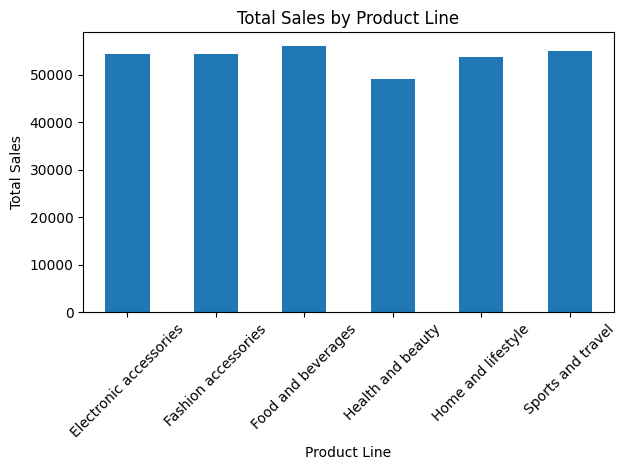

In [22]:
import matplotlib.pyplot as plt

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

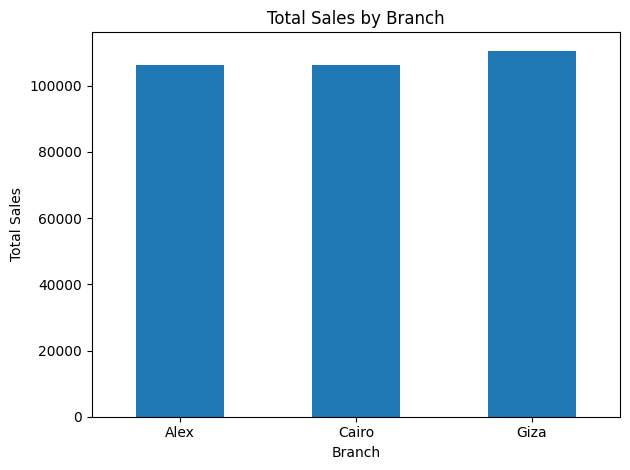

In [23]:
sales_by_branch.plot(kind="bar")

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

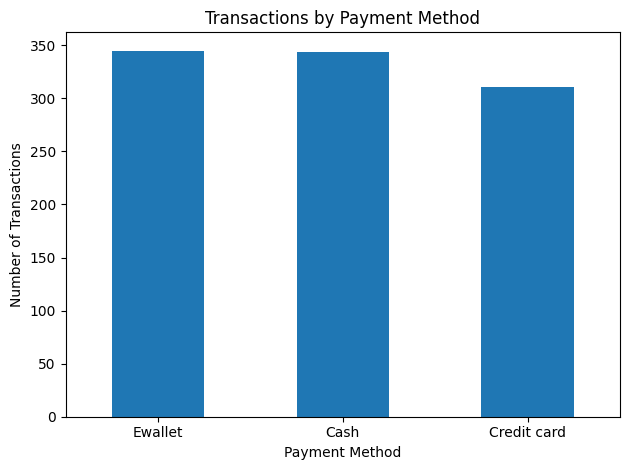

In [24]:
payment_counts.plot(kind="bar")

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

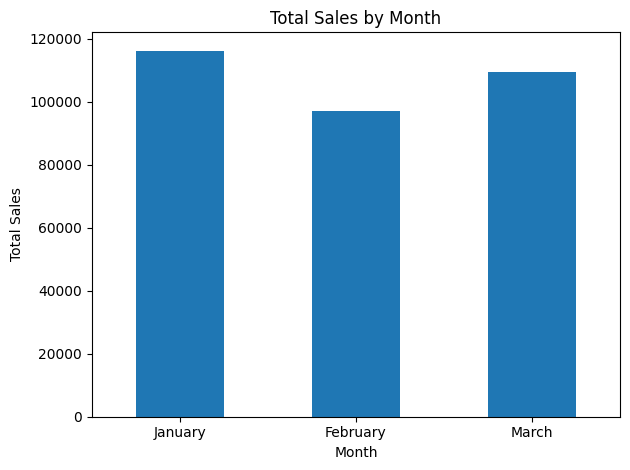

In [25]:
monthly_sales = monthly_sales.reindex(["January", "February", "March"])

monthly_sales.plot(kind="bar")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

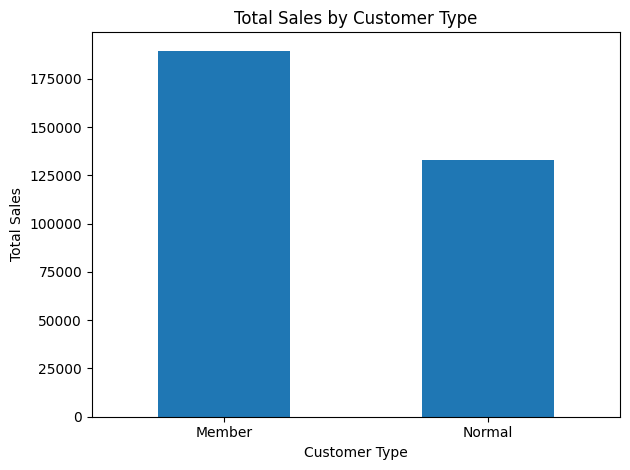

In [26]:
sales_by_customer_type.plot(kind="bar")

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

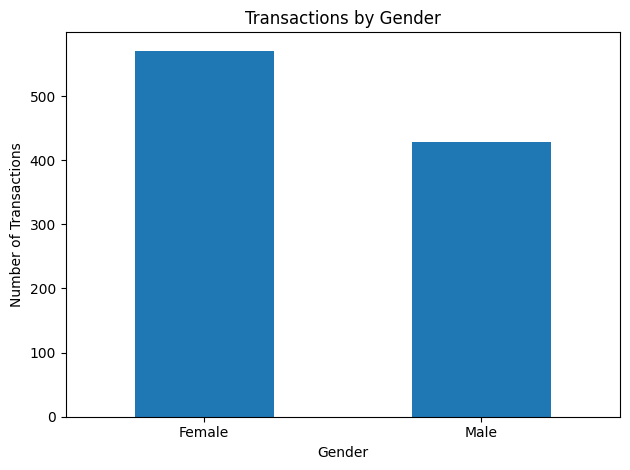

In [27]:
gender_counts.plot(kind="bar")

plt.title("Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

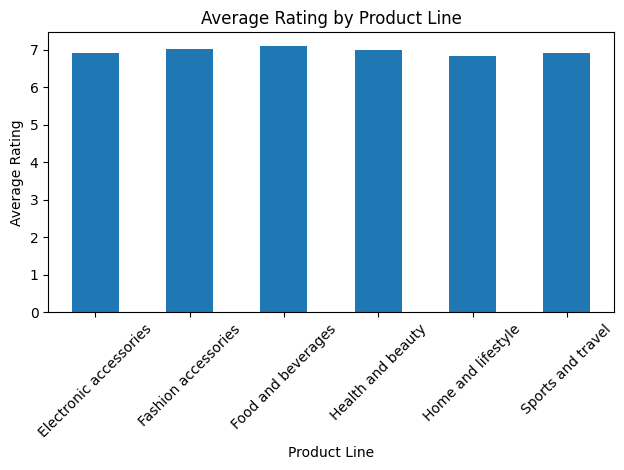

In [28]:
rating_by_product.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())
print("Final dataset shape:", cleaned_df.shape)

Missing values: 0
Duplicate rows: 0
Final dataset shape: (1000, 18)


In [30]:
cleaned_df.to_csv("/content/cleaned_supermarket_sales.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


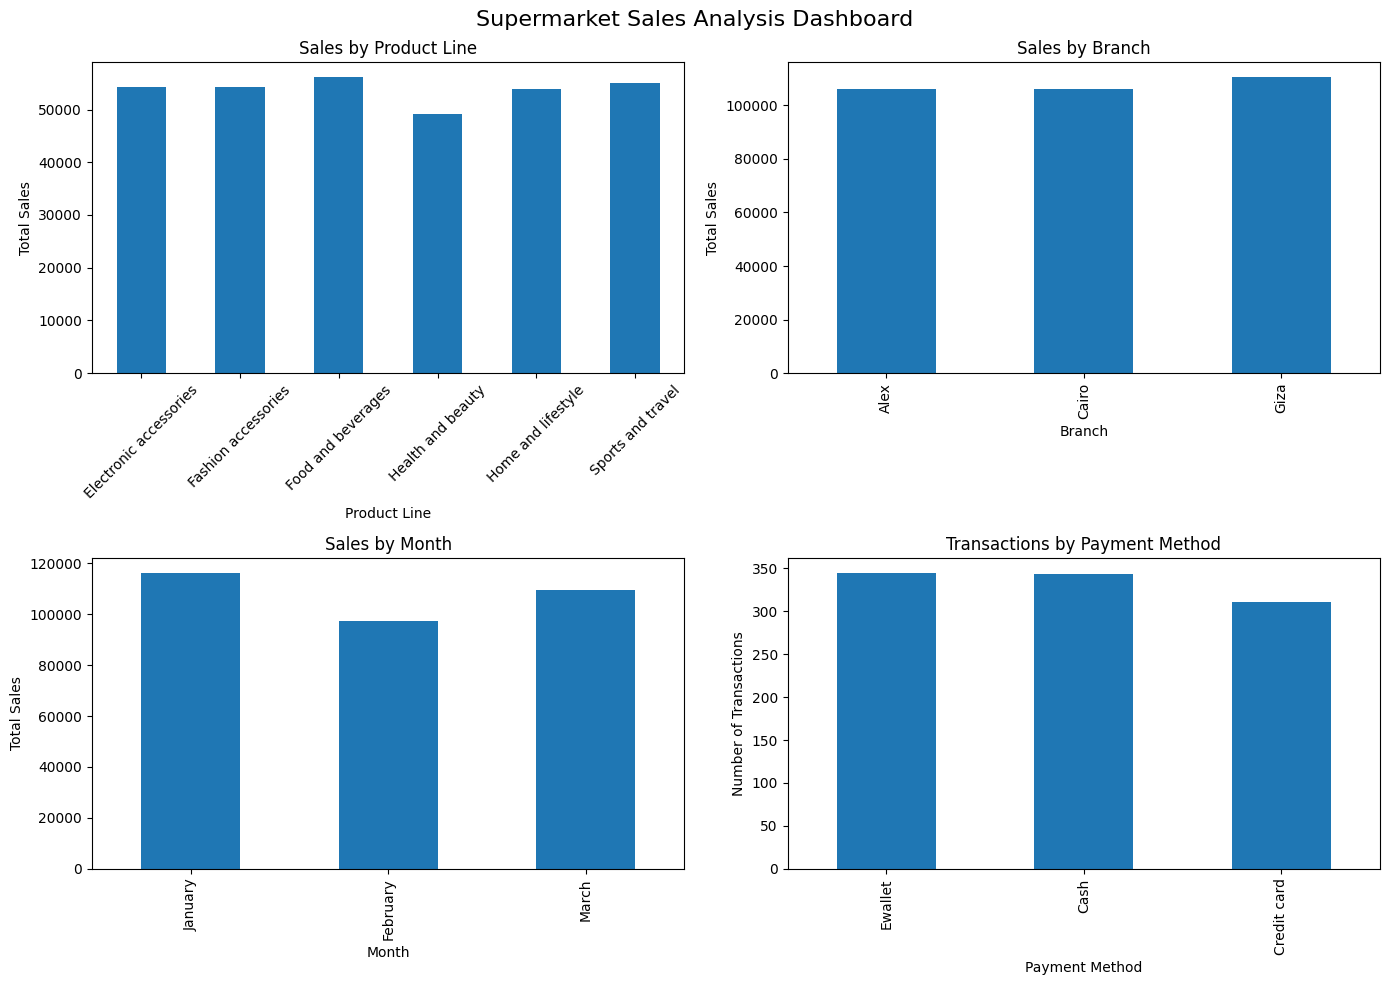

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sales by Product Line
sales_by_product.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sales by Product Line")
axes[0, 0].set_xlabel("Product Line")
axes[0, 0].set_ylabel("Total Sales")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Sales by Branch
sales_by_branch.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Sales by Branch")
axes[0, 1].set_xlabel("Branch")
axes[0, 1].set_ylabel("Total Sales")

# 3. Sales by Month
monthly_sales.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Sales by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Total Sales")

# 4. Transactions by Payment Method
payment_counts.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Transactions by Payment Method")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Number of Transactions")

plt.suptitle("Supermarket Sales Analysis Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
fig.savefig(
    "/content/supermarket_sales_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard saved successfully!")

Dashboard saved successfully!


In [33]:
print("========== PROJECT SUMMARY ==========")

print("\nDataset:")
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

print("\nData Cleaning:")
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

print("\nKey Findings:")
print("Highest sales product line:",
      sales_by_product.idxmax())
print("Highest sales branch:",
      sales_by_branch.idxmax())
print("Highest sales month:",
      monthly_sales.idxmax())
print("Most used payment method:",
      payment_counts.idxmax())
print("Highest sales customer type:",
      sales_by_customer_type.idxmax())
print("Highest rated product line:",
      rating_by_product.idxmax())

========== PROJECT SUMMARY ==========

Dataset:
Rows: 1000
Columns: 18

Data Cleaning:
Missing values: 0
Duplicate rows: 0

Key Findings:
Highest sales product line: Food and beverages
Highest sales branch: Giza
Highest sales month: January
Most used payment method: Ewallet
Highest sales customer type: Member
Highest rated product line: Food and beverages


In [34]:
final_df = pd.read_csv("/content/cleaned_supermarket_sales.csv")

print("Saved CSV loaded successfully!")
print("Final shape:", final_df.shape)
print("Missing values:", final_df.isnull().sum().sum())
print("Duplicate rows:", final_df.duplicated().sum())

Saved CSV loaded successfully!
Final shape: (1000, 18)
Missing values: 0
Duplicate rows: 0
